<a href="https://colab.research.google.com/github/erdijova/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Classification (Comprehensive & Detailed)

This notebook is designed to closely follow *Practical Statistics for Data Scientists*, with deeper explanations, more examples, and extensive coding.

Classification is used to predict categorical outcomes.

## Introduction

Classification is a supervised learning technique where the target variable is categorical.

Key goals:
- Predict class labels
- Estimate probabilities
- Evaluate model performance

This chapter covers multiple classification methods and evaluation techniques.

## Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


## Load Dataset

We use a binary classification dataset (Titanic dataset).

In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df = df[['Survived','Pclass','Sex','Age','Fare']].dropna()
df['Sex'] = df['Sex'].map({'male':0,'female':1})
df.head()


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


## Train-Test Split

In [3]:

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Logistic Regression

Logistic regression models probability using a sigmoid function.

Output is between 0 and 1.

In [4]:

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.78      0.80        87
           1       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



## Naive Bayes

Assumes independence between features.

Simple but effective for many problems.

In [5]:

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(classification_report(y_test, y_pred_nb))


              precision    recall  f1-score   support

           0       0.79      0.78      0.79        87
           1       0.67      0.68      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



## Discriminant Analysis (LDA)

Uses class separation and covariance structure.

In [6]:

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

y_pred_lda = lda_model.predict(X_test)
print(classification_report(y_test, y_pred_lda))


              precision    recall  f1-score   support

           0       0.78      0.79      0.79        87
           1       0.67      0.66      0.67        56

    accuracy                           0.74       143
   macro avg       0.73      0.73      0.73       143
weighted avg       0.74      0.74      0.74       143



## Confusion Matrix

Shows prediction vs actual classification.

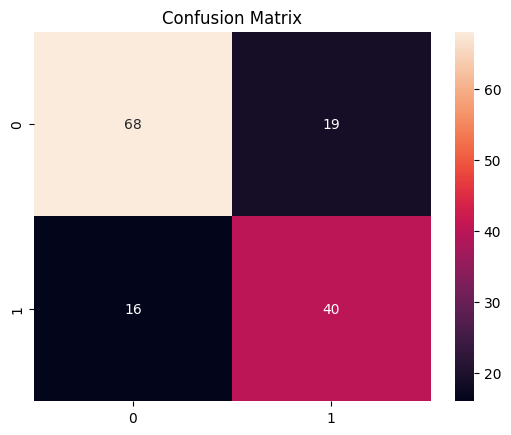

In [7]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


## Evaluation Metrics

- Accuracy: correct predictions
- Precision: TP / (TP + FP)
- Recall: TP / (TP + FN)
- Specificity: TN / (TN + FP)

These metrics are important especially for imbalanced data.

## ROC Curve & AUC

ROC curve shows tradeoff between true positive rate and false positive rate.

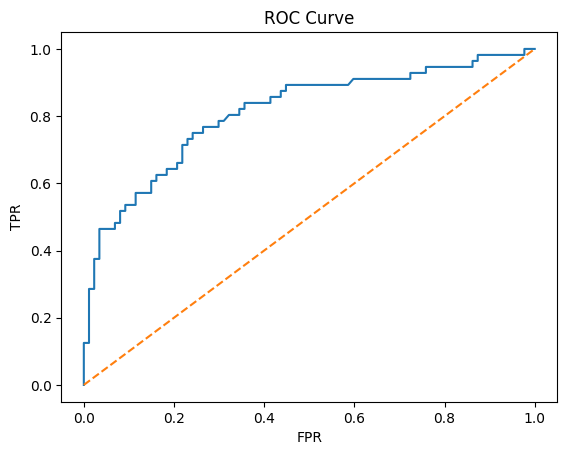

AUC: 0.8109605911330049


In [8]:

y_prob = log_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

print("AUC:", auc(fpr, tpr))


## Imbalanced Data

When one class is rare, accuracy is misleading.

Strategies:
- Undersampling
- Oversampling
- Class weighting

In [9]:

# Example: class distribution
df['Survived'].value_counts()


,count
Survived,
0,424
1,290


## Lift (Concept from Book)

Lift measures model performance compared to random selection.

Higher lift indicates better model performance.

## Conclusion

In this chapter, we explored:
- Logistic Regression
- Naive Bayes
- Discriminant Analysis
- Evaluation metrics
- ROC & AUC
- Imbalanced data handling

Classification is essential for many real-world problems such as fraud detection and medical diagnosis.